In [29]:
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [30]:
from pathlib import Path

# Dataset path
dataset_path = Path("/kaggle/input/animals10/raw-img")

# Find all image files recursively
image_paths = list(dataset_path.rglob("*.jpeg"))
image_paths += list(dataset_path.rglob("*.jpg"))
image_paths += list(dataset_path.rglob("*.png"))

print(f"Number of images: {len(image_paths)}")
print(image_paths[:5])

Number of images: 26179
[PosixPath('/kaggle/input/animals10/raw-img/cavallo/OIP-mdvOxIWAyReAoEJcMk5z4wHaJ4.jpeg'), PosixPath('/kaggle/input/animals10/raw-img/cavallo/OIP-TPYKs3XId_sMgp_6LLA6JgDMEy.jpeg'), PosixPath('/kaggle/input/animals10/raw-img/cavallo/OIP-jlVRrokx7Vu1axi8OnTX2AHaE2.jpeg'), PosixPath('/kaggle/input/animals10/raw-img/cavallo/OIP-F4QVZ71QagiynDMnFNxJUAHaEK.jpeg'), PosixPath('/kaggle/input/animals10/raw-img/cavallo/OIP-UFtUZnXq0JHZo5R8UuF80wHaFj.jpeg')]


The dataset is organized into folders, where each folder represents one class. We recursively search for every image file and store its path so we can build our dataset.

In [31]:
# Create labels from folder names
labels = [path.parent.name for path in image_paths]

# Create DataFrame
df = pd.DataFrame({
    "filepath": [str(path) for path in image_paths],
    "label": labels
})

# Display first rows
df.head()

,filepath,label
0,/kaggle/input/animals10/raw-img/cavallo/OIP-md...,cavallo
1,/kaggle/input/animals10/raw-img/cavallo/OIP-TP...,cavallo
2,/kaggle/input/animals10/raw-img/cavallo/OIP-jl...,cavallo
3,/kaggle/input/animals10/raw-img/cavallo/OIP-F4...,cavallo
4,/kaggle/input/animals10/raw-img/cavallo/OIP-UF...,cavallo


In [32]:
# Count images per class
class_counts = df["label"].value_counts().sort_index()

print(class_counts)

label
cane          4863
cavallo       2623
elefante      1446
farfalla      2112
gallina       3098
gatto         1668
mucca         1866
pecora        1820
ragno         4821
scoiattolo    1862
Name: count, dtype: int64


I created a Pandas DataFrame where each row represents one image. The DataFrame stores the image path and its class label, which gives us a structured dataset for preprocessing and model training.

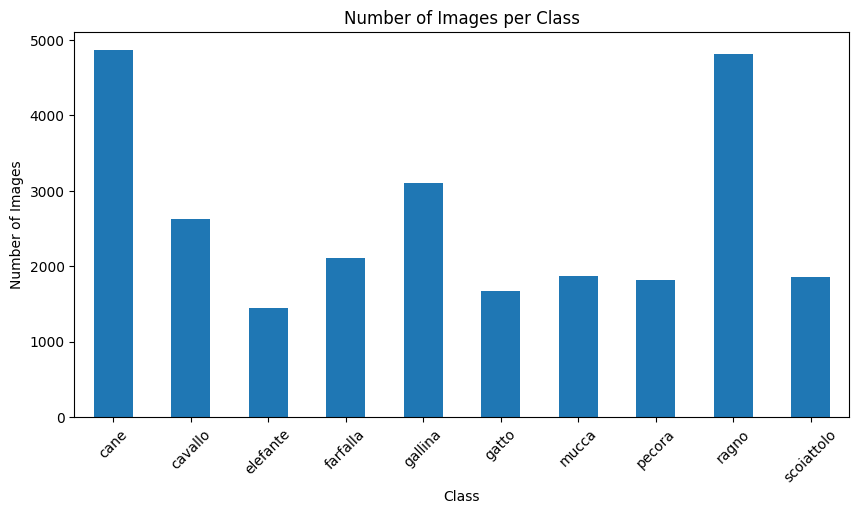

In [33]:
plt.figure(figsize=(10,5))
class_counts.plot(kind="bar")

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

Before training the CNN, I explored the dataset to understand the class distribution. This helps identify potential class imbalance, which could negatively affect the model's performance.

The dataset is not balanced.

Examples:

🐶 Dog (cane): 4,863
🕷 Spider (ragno): 4,821
🐘 Elephant (elefante): 1,446

The dataset is moderately imbalanced. Dogs and spiders have significantly more images than elephants or cats. This may bias the model towards the larger classes, so we use a stratified train/validation/test split to preserve the class distribution.


In [34]:
# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

# Second split: 10% validation, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print(f"Train:      {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test:       {len(test_df)}")

Train:      20943
Validation: 2618
Test:       2618


I split the dataset into three parts. The model learns from the training set, I use the validation set to monitor its performance during training, and I keep the test set separate for the final evaluation.

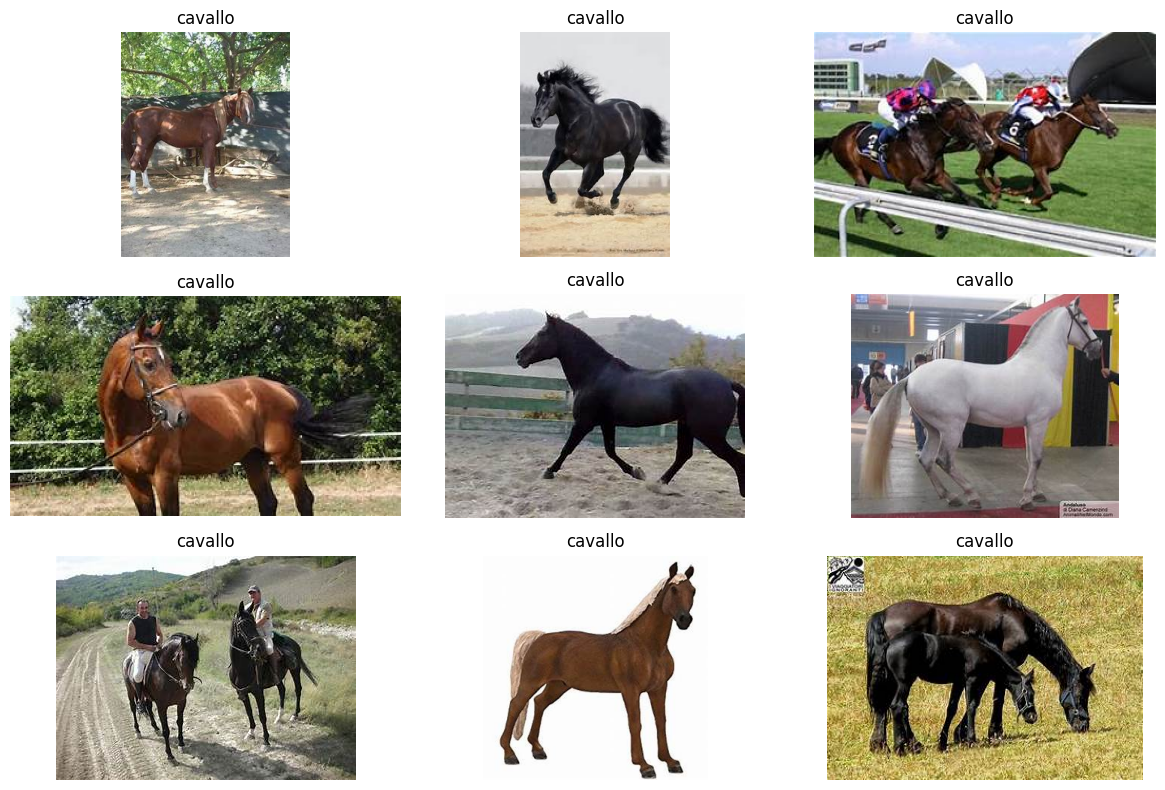

In [35]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    image = Image.open(df.iloc[i]["filepath"])
    plt.imshow(image)

    plt.title(df.iloc[i]["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

Before training the model, I visualized a few sample images to verify that the labels matched the images and that the dataset was loaded correctly. All the images are cavallo bevause the DF is currently sorted by folder, firt row come form cavallo folder - lets make it intersting and show random images

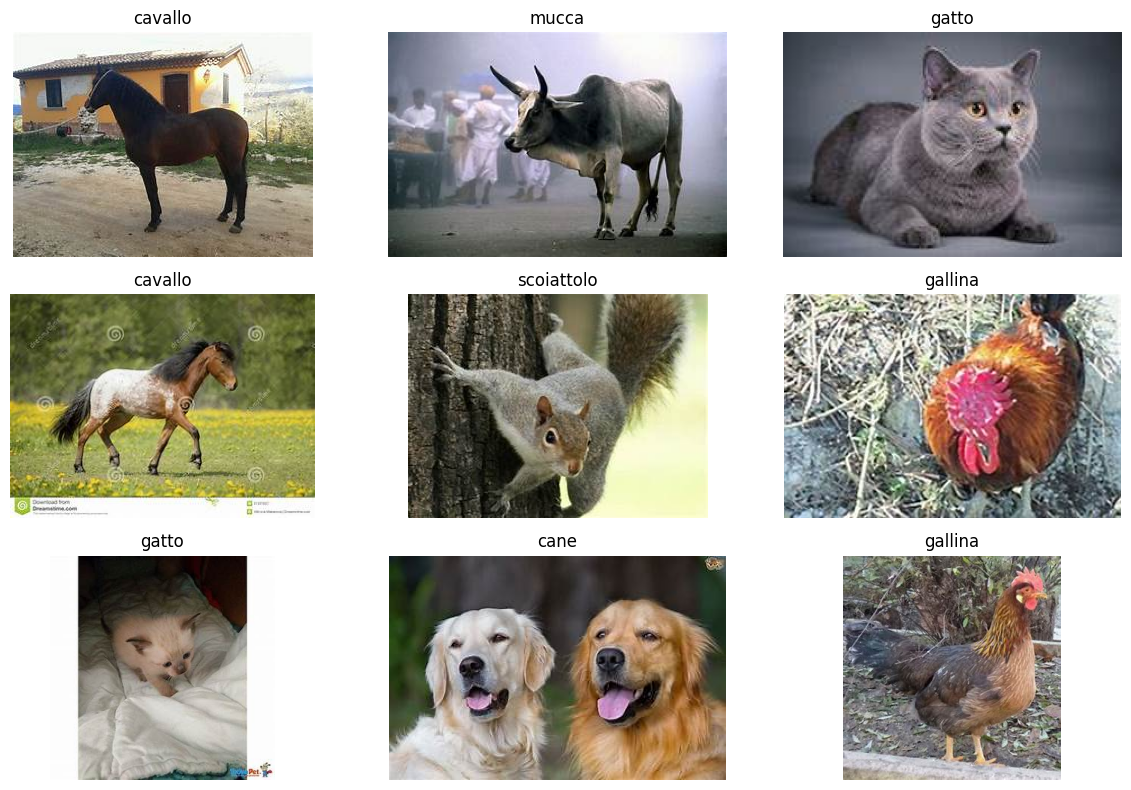

In [36]:
from PIL import Image

# Pick 9 random images
sample_df = df.sample(9, random_state=SEED)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    plt.subplot(3, 3, i + 1)

    image = Image.open(row["filepath"])
    plt.imshow(image)

    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

I displayed random images from the dataset to verify that different animal classes were loaded correctly and that the labels matched the images.

In [37]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


Until now we only had a table DF.

Now TensorFlow creates datasets that can actually be fed into a CNN.

In [38]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


What does 32, 128, 128, 3 mean?
32 → batch size
128 x 128 → image size
3 → RGB channels

In [39]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

normalize images - Images have pixel values from 0 to 255.

Neural networks train better when values are between 0 and 1.

In [40]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

I prepare the data pipeline so the GPU does not wait for images to load.

**Build simple CNN**

In [41]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

Justifying choices:

Overall:

I selected a simple CNN architecture commonly used as a baseline. I gradually increased the number of filters, used standard 3×3 kernels and ReLU activation, and matched the output layer to the 10 target classes.



Input 128,128,3

I resized all images to 128×128 pixels. This keeps enough visual detail while reducing computation time. The 3 represents the RGB color channels.

Conv2D

Convolutional layers are the core of a CNN. They automatically learn visual features such as edges, textures and shapes.

32 → 64 → 128 filters

I started with 32 filters and gradually increased them to 64 and 128. Early layers learn simple features like edges, while deeper layers learn more complex patterns such as animal faces or dots in eye or body shapes.

Kernel size = 3

A 3×3 kernel is the standard choice in CNNs because it captures local image features efficiently while keeping the model relatively small.

ReLU

I chose the ReLU activation function because it is simple, computationally efficient, and helps the model learn non-linear patterns.

MaxPooling

MaxPooling reduces the spatial dimensions of the feature maps. This decreases computation time and helps the model focus on the most important features.

Flatten

Flatten converts the 2D feature maps into a 1D vector so that it can be passed to the fully connected layers

Dense(128)

I chose 128 neurons because it provides enough capacity to learn meaningful patterns without making the model unnecessarily large.

Dense(10)

The dataset contains 10 animal classes, so the output layer has 10 neurons.

Softmax converts the output into probabilities. The class with the highest probability becomes the model's prediction.





In [42]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.3946 - loss: 1.7405 - val_accuracy: 0.5068 - val_loss: 1.4607
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5796 - loss: 1.2356 - val_accuracy: 0.5922 - val_loss: 1.2075
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6755 - loss: 0.9725 - val_accuracy: 0.6630 - val_loss: 1.0242
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7515 - loss: 0.7472 - val_accuracy: 0.6714 - val_loss: 1.0261
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8236 - loss: 0.5302 - val_accuracy: 0.6684 - val_loss: 1.1059
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8832 - loss: 0.3481 - val_accuracy: 0.6743 - val_loss: 1.2758
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9232 - loss: 0.2318 - val_accuracy: 0.6638 - val_loss: 1.5180
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9520 - loss: 0.1503 - 

The CNN learned the training data very well, reaching about 97% training accuracy. However, the validation accuracy remained around 66%, indicating overfitting. This means the model memorized the training images instead of learning patterns that generalize well to unseen data. My next step is to reduce overfitting using regularization techniques and compare the baseline CNN with a transfer learning model.

In [44]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

I added a Dropout layer to reduce overfitting. During training, Dropout randomly disables some neurons, which encourages the model to learn more robust and general patterns instead of memorizing the training data.

In [45]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

Hypothesis: The baseline CNN overfits. By adding Dropout and Early Stopping, we expect the validation performance to improve or at least become more stable.

In [49]:
history_dropout = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7133 - loss: 0.8081 - val_accuracy: 0.6774 - val_loss: 0.9999
Epoch 2/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7353 - loss: 0.7343 - val_accuracy: 0.6818 - val_loss: 1.0812
Epoch 3/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7596 - loss: 0.6716 - val_accuracy: 0.6883 - val_loss: 1.0285


In [47]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [48]:
history_dropout = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]

“The first CNN overfitted. After adding Dropout and Early Stopping, the model memorizes less and generalizes better.”)

Epoch 1/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.3178 - loss: 1.9526 - val_accuracy: 0.4510 - val_loss: 1.5916
Epoch 2/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4540 - loss: 1.5815 - val_accuracy: 0.5312 - val_loss: 1.3636
Epoch 3/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5213 - loss: 1.3785 - val_accuracy: 0.6227 - val_loss: 1.1593
Epoch 4/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5667 - loss: 1.2499 - val_accuracy: 0.6394 - val_loss: 1.0954
Epoch 5/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6142 - loss: 1.1170 - val_accuracy: 0.6476 - val_loss: 1.0740
Epoch 6/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6526 - loss: 1.0042 - val_accuracy: 0.6680 - val_loss: 1.0067
Epoch 7/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.6824 - loss: 0.9115 - val_accuracy: 0.6787 - val_loss: 0.9814
Epoch 8/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7108 - loss: 0.8132 - 

The first CNN overfitted. After adding Dropout and Early Stopping, the model memorizes less and generalizes better
**bold text**
Current result around epoch 10:

Training accuracy: 75.5%
Validation accuracy: 67.9%

This is better behavior than before.

Before:

Training: 97%
Validation: 66%
Clear overfitting

Now:

Training and validation are much closer
Dropout reduced memorization
Validation is slightly better/stabler


Dropout reduced overfitting, but the simple CNN is limited. Next I will use Transfer Learning to improve performance.

In [50]:
baseline_val_accuracy = max(history_dropout.history["val_accuracy"])
print(f"Best baseline validation accuracy: {baseline_val_accuracy:.2%}")

Best baseline validation accuracy: 68.83%


My baseline CNN reached around 69% validation accuracy. This gives me a reference point. Next, I use Transfer Learning to see if a pre-trained model performs better

In [51]:
base_model = keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Next Step  Build the Transfer Learning model

In [54]:
transfer_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

Instead of training a CNN from scratch, I reused MobileNetV2, which was pre-trained on ImageNet. I froze the feature extractor and trained only a small classification head for the 10 animal classes.

Now Compile -> ADAM -> optimizer the same so the comparison is fair

In [56]:
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train - Run Experiment -> Basline CCN 68.38% vs. MobileNetV2 ?

Hypothesis is:

A pre-trained MobileNetV2 should outperform our simple CNN because it already learned useful visual features from ImageNet.

In [57]:
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 51s 52ms/step - accuracy: 0.8745 - loss: 0.4050 - val_accuracy: 0.9293 - val_loss: 0.2263
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9290 - loss: 0.2279 - val_accuracy: 0.9316 - val_loss: 0.2173
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9381 - loss: 0.1931 - val_accuracy: 0.9297 - val_loss: 0.2199
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9442 - loss: 0.1767 - val_accuracy: 0.9352 - val_loss: 0.2128
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9479 - loss: 0.1603 - val_accuracy: 0.9270 - val_loss: 0.2279
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9479 - loss: 0.1559 - val_accuracy: 0.9297 - val_loss: 0.2247
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9502 - loss: 0.1489 - val_accuracy: 0.9305 - val_loss: 0.2288


| Model        |      Validation Accuracy |
| ------------ | -----------------------: |
| Baseline CNN |               **68.83%** |
| MobileNetV2  | **~93.5%** (best so far) |


Why is MobileNetVZ better?

MobileNetV2 already knows these visual features because it was trained on ImageNet over a million images across many classes.


My baseline CNN achieved about 69% validation accuracy. To improve performance, I applied transfer learning using MobileNetV2. Since MobileNetV2 was already trained on ImageNet, it had learned useful visual features. By freezing the pre-trained layers and training only a new classifier, the validation accuracy increased to approximately 93%

In [58]:
transfer_val_accuracy = max(history_transfer.history["val_accuracy"])

print(f"Best MobileNetV2 validation accuracy: {transfer_val_accuracy:.2%}")
print(f"Best baseline CNN validation accuracy: {baseline_val_accuracy:.2%}")

Best MobileNetV2 validation accuracy: 93.52%
Best baseline CNN validation accuracy: 68.83%


I compared the baseline CNN against MobileNetV2 using the best validation accuracy from training.

| Model        | Validation Accuracy |
| ------------ | ------------------: |
| Baseline CNN |          **68.83%** |
| MobileNetV2  |          **93.52%** |


**Evaluate the final model**

Accuracy
Precision
Recall
F1-score
Confusion Matrix

In [59]:
import numpy as np

# Predict probabilities
predictions = transfer_model.predict(val_ds)

# Convert probabilities to class IDs
y_pred = np.argmax(predictions, axis=1)

164/164 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step


The model predicts a probability for every class. I use argmax() to select the class with the highest probability as the final prediction.**bold text**

In [60]:
# Collect the true labels
y_true = np.concatenate([labels.numpy() for _, labels in val_ds])

print("Number of true labels:", len(y_true))
print("Number of predictions:", len(y_pred))

Number of true labels: 5235
Number of predictions: 5235


To evaluate the model, I compared the predicted labels with the ground truth labels from the validation dataset.

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       956
           1       0.94      0.90      0.92       534
           2       0.94      0.94      0.94       256
           3       0.95      0.96      0.96       406
           4       0.96      0.95      0.96       641
           5       0.92      0.86      0.89       303
           6       0.86      0.89      0.87       364
           7       0.93      0.87      0.90       363
           8       0.98      0.97      0.98      1025
           9       0.92      0.94      0.93       387

    accuracy                           0.94      5235
   macro avg       0.93      0.92      0.93      5235
weighted avg       0.94      0.94      0.94      5235



classes are shown as 0-9, better to display animals name

In [62]:
from sklearn.metrics import classification_report

class_names = train_ds.class_names

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [63]:
class_names = [
    "cane",
    "cavallo",
    "elefante",
    "farfalla",
    "gallina",
    "gatto",
    "mucca",
    "pecora",
    "ragno",
    "scoiattolo"
]

In [64]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        cane       0.90      0.96      0.93       956
     cavallo       0.94      0.90      0.92       534
    elefante       0.94      0.94      0.94       256
    farfalla       0.95      0.96      0.96       406
     gallina       0.96      0.95      0.96       641
       gatto       0.92      0.86      0.89       303
       mucca       0.86      0.89      0.87       364
      pecora       0.93      0.87      0.90       363
       ragno       0.98      0.97      0.98      1025
  scoiattolo       0.92      0.94      0.93       387

    accuracy                           0.94      5235
   macro avg       0.93      0.92      0.93      5235
weighted avg       0.94      0.94      0.94      5235



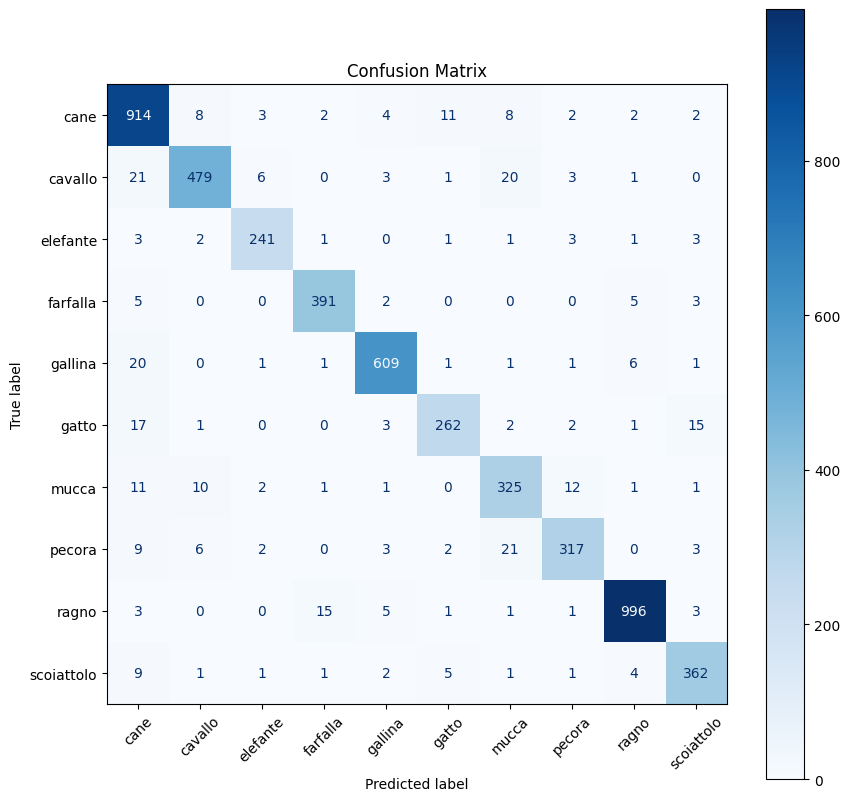

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

In [66]:
transfer_model.save("animals10_mobilenetv2.keras")

In [67]:
import os

print(os.path.exists("animals10_mobilenetv2.keras"))

True
